This note introduces a **Conditional Variational Autoencoder (CVAE)** for image generation on the **MNIST** dataset. The goal is to learn a deep latent-variable model that can synthesize digits conditioned on a desired label—e.g., generate a “2” on demand—and optionally modulate the writing style.


## **Problem setup**

We observe training pairs of handwritten digits and their class labels
$$
\mathcal{D} = {(x^{(i)}, y^{(i)})}_{i=1}^N,
$$
where $x^{(i)} \in \mathbb{R}^{28\times28}$ is an image and $y^{(i)} \in {0,\dots,9}$ is the corresponding digit label.
Our goal is to model the conditional data distribution
$$
p_\theta(x \mid y),
$$
so that, given any label $y$, the model can generate realistic samples $x$ of that digit.



100%|██████████| 9.91M/9.91M [00:00<00:00, 17.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 478kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.48MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.32MB/s]


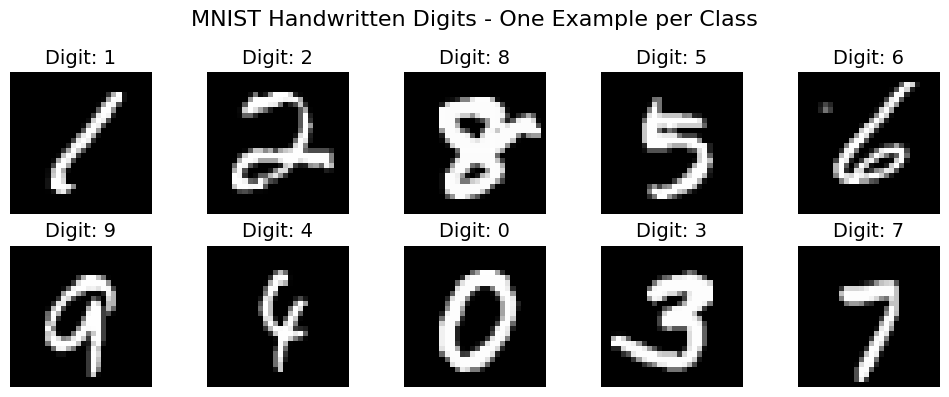

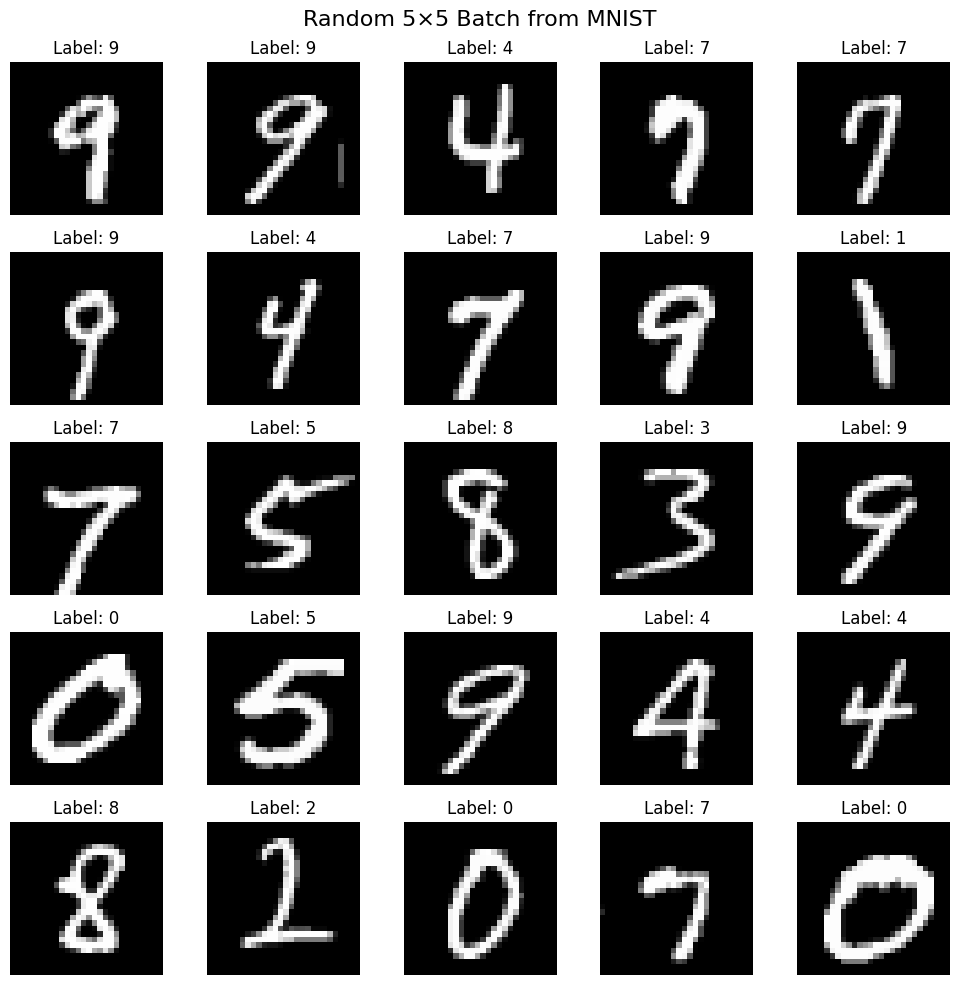

Dataset loaded! Total training examples: 60000
Image shape: torch.Size([1, 28, 28]) → 1×28×28 (grayscale)


In [22]:
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

# Set random seed for reproducibility
random.seed(42)
torch.manual_seed(42)

# Define transform (convert to tensor and normalize to [0,1] or [-1,1] — we'll use [0,1] for now)
transform = transforms.Compose([
    transforms.ToTensor(),                    # Converts PIL Image to tensor: [0, 255] → [0.0, 1.0]
    # transforms.Normalize((0.5,), (0.5,))    # Optional: map to [-1, 1] (common for VAEs)
])

# Load MNIST training set
train_dataset = datasets.MNIST(root='./data', 
                               train=True, 
                               download=True, 
                               transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# For visualization: collect one example per class (0 to 9)
examples = []
labels_seen = set()

for images, labels in train_loader:
    for img, lbl in zip(images, labels):
        lbl = lbl.item()
        if lbl not in labels_seen:
            examples.append((img, lbl))
            labels_seen.add(lbl)
        if len(examples) == 10:
            break
    if len(examples) == 10:
        break

# Plot one example per digit
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
axes = axes.ravel()

for i in range(10):
    img, label = examples[i]
    axes[i].imshow(img.squeeze(), cmap='gray')
    axes[i].set_title(f'Digit: {label}', fontsize=14)
    axes[i].axis('off')

plt.suptitle('MNIST Handwritten Digits - One Example per Class', fontsize=16)
plt.tight_layout()
plt.show()

# Also show a random batch for more variety
dataiter = iter(train_loader)
images, labels = next(dataiter)

plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i+1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.title(f'Label: {labels[i].item()}')
    plt.axis('off')
plt.suptitle('Random 5×5 Batch from MNIST', fontsize=16)
plt.tight_layout()
plt.show()

print(f"Dataset loaded! Total training examples: {len(train_dataset)}")
print(f"Image shape: {images[0].shape} → 1×28×28 (grayscale)")

### **Model setup**

We introduce a latent variable $ z \in \mathbb{R}^m $ that captures continuous variations in handwriting style.
The joint distribution is defined as

$$
p_\theta(x, z \mid y) = p_\theta(x \mid z, y) p(z),
$$

where $ p(z) = \mathcal{N}(0, I) $ is a fixed Gaussian prior.

* **Decoder (generative model):** $ p_\theta(x \mid z, y) $ reconstructs the image given latent code $z$ and label $y$.
* **Encoder (inference model):** we approximate the true posterior $ p_\theta(z \mid x, y) $ with

$$
q_\phi(z \mid x, y) = \mathcal{N}\big(\mu_\phi(x, y), \mathrm{diag}(\sigma_\phi^2(x, y))\big).
$$



### **Derivation of the Conditional ELBO**

Our goal is to maximize the conditional log-likelihood of the data:

$$
\log p_\theta(x \mid y).
$$

Since this is intractable, we derive a lower bound (the **conditional ELBO**):

$$
\log p_\theta(x \mid y)
\ge
\mathbb{E}_{q_\phi(z \mid x, y)}[\log p_\theta(x \mid z, y)]

D_{\mathrm{KL}}\big(q_\phi(z \mid x, y) | p(z)\big).
$$

### **Training objective**

The right-hand side is the objective we actually optimize.
We **maximize** the ELBO with respect to parameters $\theta$ and $\phi$, or equivalently, **minimize** the negative ELBO (which is used as the loss in code):

$$
\mathcal{L}_{\text{CVAE}}(x, y)
= -\mathbb{E}_{q_\phi(z \mid x, y)}[\log p_\theta(x \mid z, y)]
+ D_{\mathrm{KL}}\big(q_\phi(z \mid x, y) | p(z)\big).
$$

- The first term (reconstruction loss) ensures that decoded samples resemble the input image.
- The second term (KL divergence) regularizes the latent distribution so that it stays close to the Gaussian prior, which keeps sampling stable during generation.




In [23]:
class Encoder(nn.Module):
    def __init__(self, y_dim=10, z_dim=16):
        super().__init__()
        # Input: x (1×28×28) + y (10) → concatenate on channel dim → 11×28×28
        self.conv = nn.Sequential(
            nn.Conv2d(img_channels + y_dim, 32, kernel_size=4, stride=2, padding=1),  # → 32×14×14
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),                   # → 64×7×7
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=7),                                        # → 128×1×1
            nn.ReLU(),
        )
        # Flatten → 128
        self.fc_mu = nn.Linear(128 + y_dim, z_dim)         # μ(x,y)
        self.fc_logvar = nn.Linear(128 + y_dim, z_dim)     # log σ²(x,y)

    def forward(self, x, y):
        # x: (B, 1, 28, 28), y: (B, 10)
        B = x.shape[0]
        y_img = y.view(B, y_dim, 1, 1).expand(B, y_dim, 28, 28)  # tile label across image
        x_cond = torch.cat([x, y_img], dim=1)                    # (B, 11, 28, 28)
        
        h = self.conv(x_cond)                                    # (B, 128, 1, 1)
        h = h.view(B, -1)                                        # (B, 128)
        
        h = torch.cat([h, y], dim=1)                             # condition again in FC
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar


class Decoder(nn.Module):
    def __init__(self, y_dim=10, z_dim=16):
        super().__init__()
        self.fc = nn.Linear(z_dim + y_dim, 128 * 7 * 7)
        
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),   # → 64×14×14
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),    # → 32×28×28
            nn.ReLU(),
            nn.ConvTranspose2d(32, img_channels, kernel_size=5, padding=2),   # → 1×28×28
            nn.Sigmoid()  # output in [0,1] since we use binary cross-entropy or MSE on [0,1] images
        )

    def forward(self, z, y):
        # z: (B, z_dim), y: (B, y_dim)
        h = torch.cat([z, y], dim=1)                     # (B, z_dim + y_dim)
        h = self.fc(h).view(-1, 128, 7, 7)               # (B, 128, 7, 7)
        x_recon = self.deconv(h)                         # (B, 1, 28, 28)
        return x_recon


class CVAE(nn.Module):
    def __init__(self, y_dim=10, z_dim=16):
        super().__init__()
        self.z_dim = z_dim
        self.y_dim = y_dim
        self.encoder = Encoder(y_dim, z_dim)
        self.decoder = Decoder(y_dim, z_dim)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x, y):
        """
        x: (B, 1, 28, 28)
        y: (B, 10) one-hot
        Returns: x_recon, mu, logvar
        """
        mu, logvar = self.encoder(x, y)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decoder(z, y)
        return x_recon, mu, logvar

    # Helper for pure generation (no input image)
    def sample(self, y, device='cpu'):
        """
        Generate new digits conditioned on label y
        y: (B, 10) tensor of one-hot labels
        """
        self.eval()
        with torch.no_grad():
            z = torch.randn(y.shape[0], self.z_dim, device=device)
            samples = self.decoder(z.to(device), y.to(device))
        return samples

In [24]:
# loss
def loss_function(x_recon, x, mu, logvar):
    """
    Negative Conditional ELBO (to minimize)
    x_recon: reconstructed images (B, 1, 28, 28)
    x      : original images      (B, 1, 28, 28)
    mu, logvar: encoder outputs   (B, z_dim)
    """
    # 1. Reconstruction loss: Binary Cross Entropy (pixel-wise)
    #    Flatten to (B, 784) → BCEWithLogits could also be used, but since we have Sigmoid output → BCE
    recon_loss = F.binary_cross_entropy(x_recon, x, reduction='sum')  # sum over pixels & batch
    
    # 2. KL divergence: closed-form for two diagonal Gaussians
    #    -0.5 * sum(1 + log(σ²) - μ² - σ²)
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    
    total_loss = recon_loss + kl_loss
    
    # We return per-batch averages for monitoring
    batch_size = x.size(0)
    return (total_loss / batch_size,
            recon_loss / batch_size,
            kl_loss / batch_size)

In [27]:
# training
z_dim = 16
y_dim = 10          # one-hot label dimension
img_channels = 1
hidden_dim = 512    # size of fully-connected layers
batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CVAE(y_dim=10, z_dim=16).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

epochs = 30
### don't edit this !!!
for epoch in range(1, epochs+1):
    model.train()
    total_loss = 0.0
    total_recon = 0.0
    total_kl = 0.0
    for x, y_label in train_loader:          # y_label is integer class (B,)
        x = x.to(device)                     # (B, 1, 28, 28)
        
        # Convert integer label → one-hot
        y = F.one_hot(y_label, num_classes=10).float().to(device)  # (B, 10)
        
        optimizer.zero_grad()
        x_recon, mu, logvar = model(x, y)

        loss, recon_loss, kl_loss = loss_function(x_recon, x, mu, logvar)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        total_recon += recon_loss.item() * x.size(0)
        total_kl += kl_loss.item() * x.size(0)

    n = len(train_loader.dataset)
    print(f"Epoch {epoch:02d}  Loss per example: {total_loss / n:.4f}  "
          f"Recon: {total_recon / n:.4f}  KL: {total_kl / n:.4f}")

Epoch 01  Loss per example: 175.7587  Recon: 171.8690  KL: 3.8897
Epoch 02  Loss per example: 120.5447  Recon: 108.6474  KL: 11.8973
Epoch 03  Loss per example: 109.3073  Recon: 95.7958  KL: 13.5115
Epoch 04  Loss per example: 104.0290  Recon: 89.2221  KL: 14.8070
Epoch 05  Loss per example: 100.6788  Recon: 85.2113  KL: 15.4676
Epoch 06  Loss per example: 99.0514  Recon: 83.3219  KL: 15.7295
Epoch 07  Loss per example: 97.9981  Recon: 82.1582  KL: 15.8399
Epoch 08  Loss per example: 97.0931  Recon: 81.1895  KL: 15.9036
Epoch 09  Loss per example: 96.5340  Recon: 80.5193  KL: 16.0147
Epoch 10  Loss per example: 96.0454  Recon: 79.9500  KL: 16.0954
Epoch 11  Loss per example: 95.3857  Recon: 79.1372  KL: 16.2486
Epoch 12  Loss per example: 94.9631  Recon: 78.5617  KL: 16.4014
Epoch 13  Loss per example: 94.5923  Recon: 78.0797  KL: 16.5126
Epoch 14  Loss per example: 94.0988  Recon: 77.4971  KL: 16.6017
Epoch 15  Loss per example: 93.7322  Recon: 77.0228  KL: 16.7094
Epoch 16  Loss per 

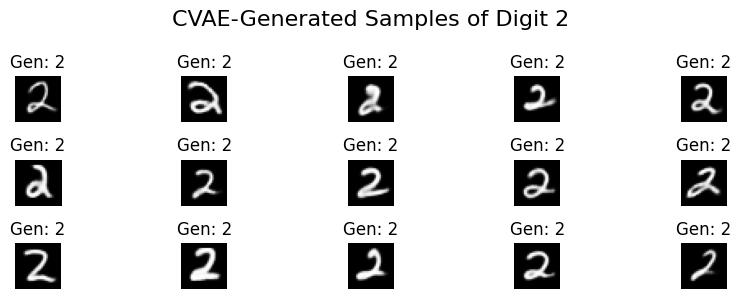

In [28]:
# model inferencing + visualization
model.eval()
with torch.no_grad():
    # choose the digit you want to generate
    digit = 2                    # change this to any digit 0–9
    n = 15                       # number of samples per digit (e.g., 15 → 3×5 grid)
    
    # Create one-hot vector for the chosen digit
    y_label = torch.full((n,), digit, dtype=torch.long, device=device)
    y = F.one_hot(y_label, num_classes=10).float()   # (n, 10)

    # Sample random latent vectors from prior
    z = torch.randn(n, model.z_dim, device=device)    # (n, z_dim)

    # Decode to images
    x_gen = model.decoder(z, y).cpu()                 # (n, 1, 28, 28)

# visualize
plt.figure(figsize=(9, 3))
for i in range(n):
    plt.subplot(3, 5, i + 1)
    plt.imshow(x_gen[i].squeeze(), cmap='gray')
    plt.title(f'Gen: {digit}')
    plt.axis('off')
plt.suptitle(f'CVAE-Generated Samples of Digit {digit}', fontsize=16)
plt.tight_layout()
plt.show()

### Student ID Generation
After training your CVAE model, define a function that takes your 9-digit student ID as input and generates one digit per number in your ID. Each digit must be conditioned on its corresponding label (0–9). Arrange the generated digits horizontally in a 1×9 grid to visually display your complete student ID as a sequence of generated MNIST-style digits. Include this final generated image in your report.

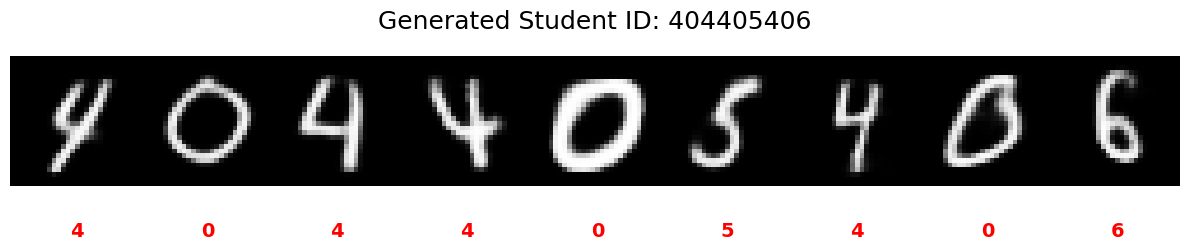

tensor([[[3.7857e-06, 2.8949e-07, 1.1671e-07,  ..., 7.4058e-05,
          1.6742e-04, 5.0169e-04],
         [3.2019e-07, 1.0536e-07, 5.9374e-08,  ..., 4.2383e-05,
          1.9363e-05, 3.5714e-05],
         [2.5766e-07, 2.8496e-07, 4.3997e-07,  ..., 5.1601e-05,
          7.5277e-05, 2.5269e-05],
         ...,
         [8.4709e-06, 8.3412e-07, 1.5353e-07,  ..., 2.3593e-06,
          2.1242e-06, 3.2659e-06],
         [2.7937e-05, 8.4089e-07, 2.3669e-07,  ..., 5.6499e-08,
          3.1365e-07, 2.6744e-06],
         [1.7080e-04, 3.9743e-05, 5.9360e-06,  ..., 1.5120e-07,
          1.5216e-06, 2.3146e-05]]])

In [29]:
def generate_student_digits(model, student_id, device='cpu'):
    """
    Generates one MNIST-style digit for each digit in your student ID.
    Arranges them horizontally as a 1×9 image.
    
    Args:
        model: Trained CVAE
        student_id: int (9 digits, e.g., 404405406)
        device: 'cpu' or 'cuda'
    """
    model.eval()
    student_str = str(student_id)
    if len(student_str) != 9:
        raise ValueError("Student ID must be exactly 9 digits!")
    
    digits = [int(d) for d in student_str]
    n = 9
    
    with torch.no_grad():
        # One-hot labels for each digit in the ID
        y_labels = torch.tensor(digits, device=device)                    # (9,)
        y = F.one_hot(y_labels, num_classes=10).float()                  # (9, 10)
        
        # Sample 9 random latent vectors from prior
        z = torch.randn(n, model.z_dim, device=device)                    # (9, z_dim)
        
        # Generate digits
        generated = model.decoder(z, y).cpu()                             # (9, 1, 28, 28)
        
        # Create horizontal strip
        strip = torch.cat([generated[i] for i in range(9)], dim=2)        # (1, 28, 252)
        
        # Plot
        plt.figure(figsize=(12, 3))
        plt.imshow(strip.squeeze(), cmap='gray')
        plt.axis('off')
        plt.title(f"Generated Student ID: {student_id}", fontsize=18, pad=20)
        
        # Add digit labels below
        for i, d in enumerate(digits):
            plt.text(14 + 28*i, 35, str(d), fontsize=14, ha='center', va='top', 
                     color='red', weight='bold')
        
        plt.tight_layout()
        plt.show()
        
        return strip

# Run it!
generate_student_digits(model, 404405406, device)

### **Latent Space Exploration**
To demonstrate that your CVAE has learned a meaningful latent representation, write a function that visualizes the latent space of the model.
Select **two random latent directions** in $z$-space, fix a target digit label $y$, and generate a **9×9 grid** of samples by varying these two directions from negative to positive values.
The center of the grid should correspond to $z = 0$ (the mean latent vector), while moving along the axes explores different variations of handwriting style.
After visualizing, **describe what each direction appears to represent**—for example, changes in stroke thickness, slant, or digit shape—and discuss whether the transformations look smooth and interpretable.



=== Latent traversal for digit 0 ===


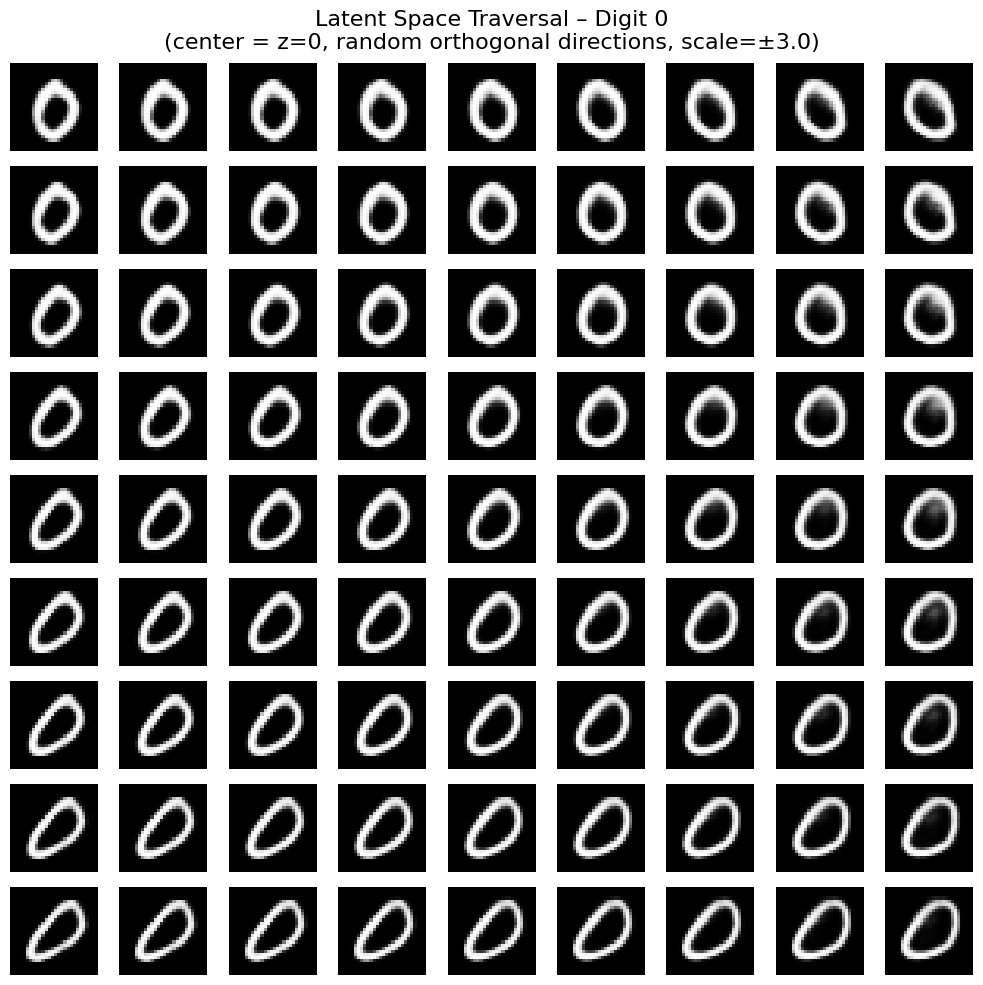


=== Latent traversal for digit 1 ===


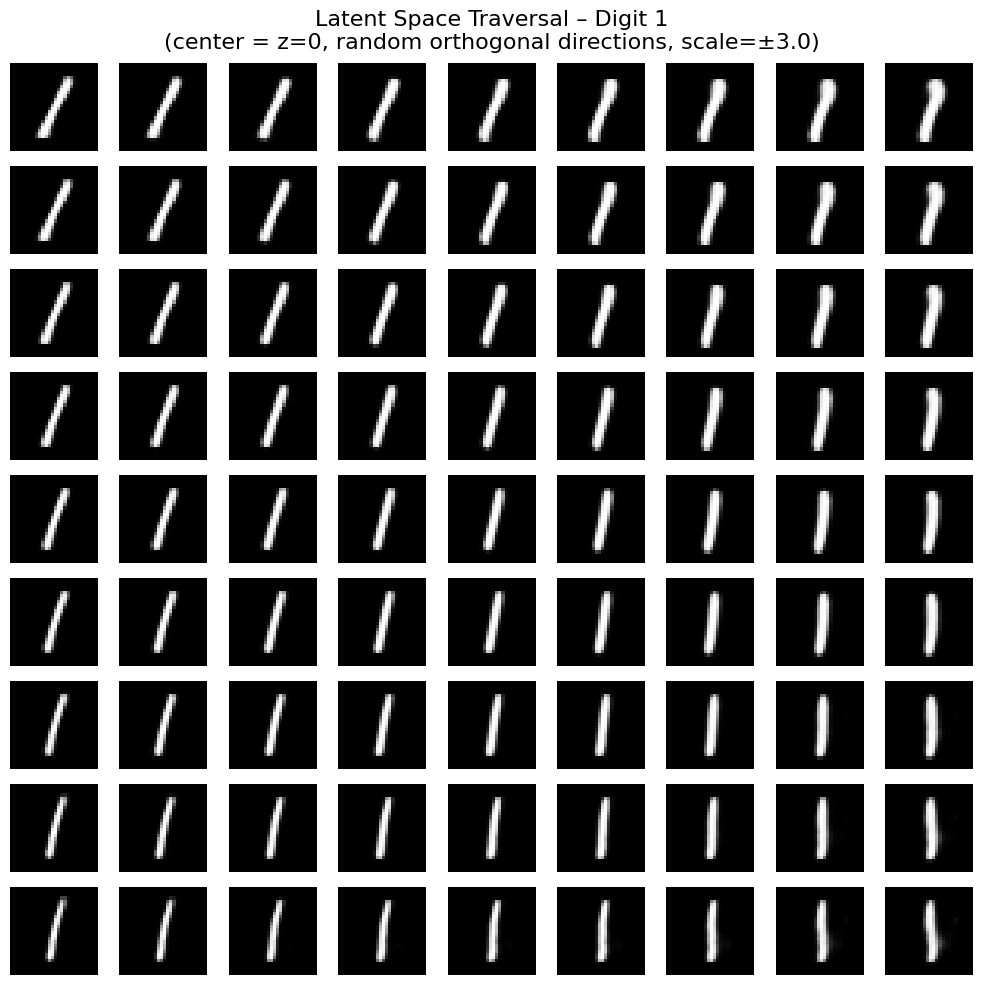


=== Latent traversal for digit 3 ===


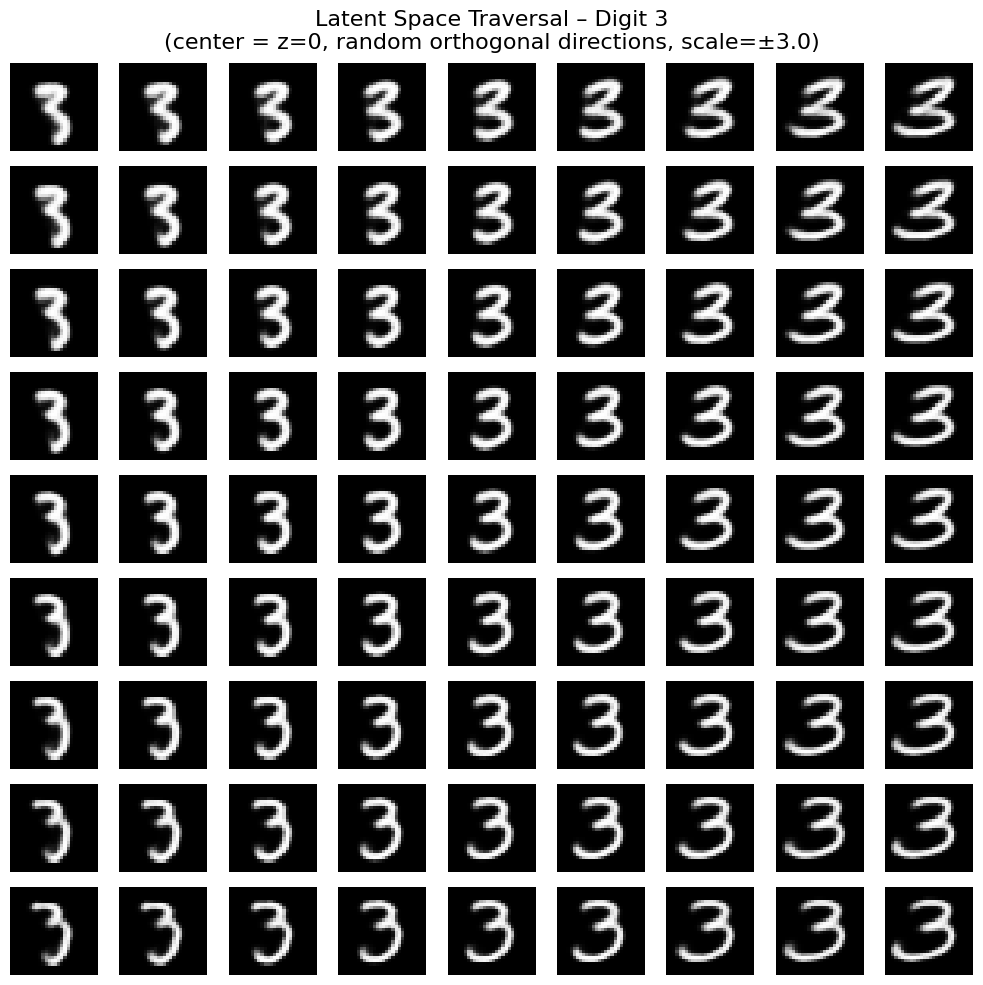


=== Latent traversal for digit 5 ===


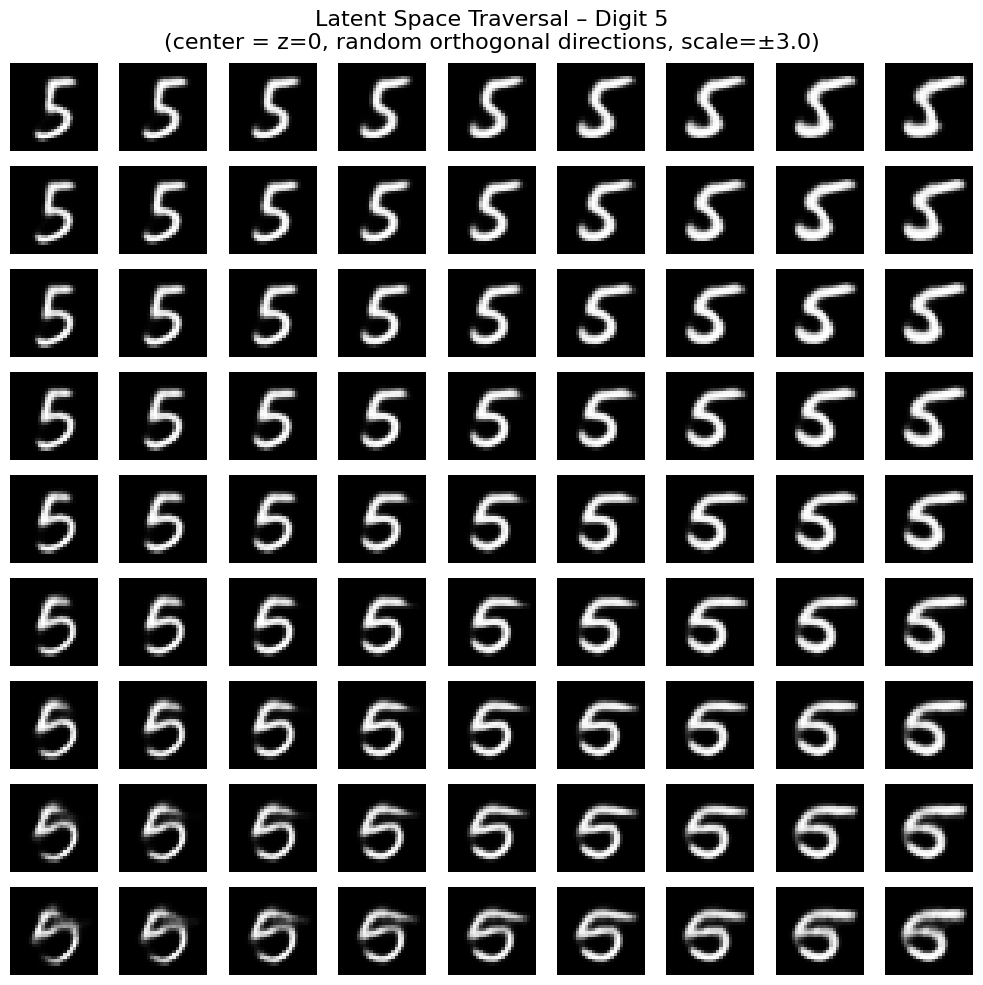


=== Latent traversal for digit 7 ===


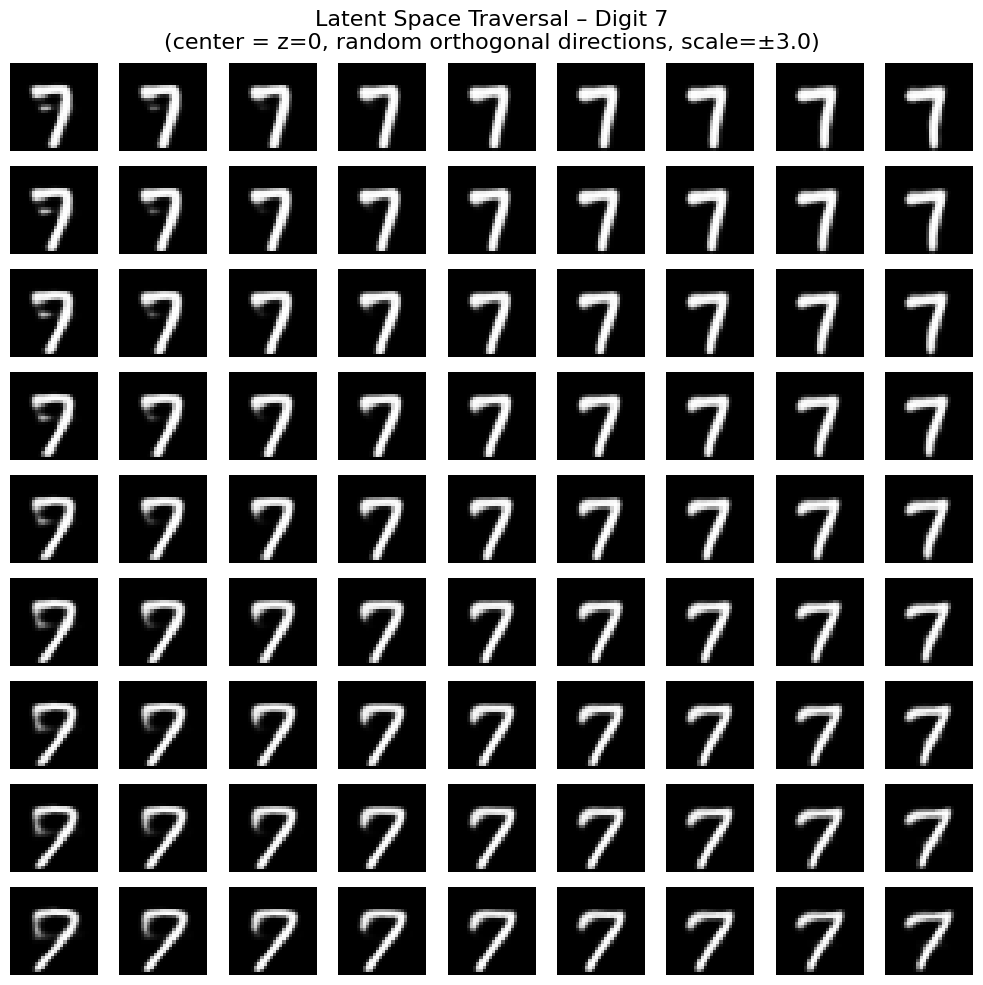


=== Latent traversal for digit 8 ===


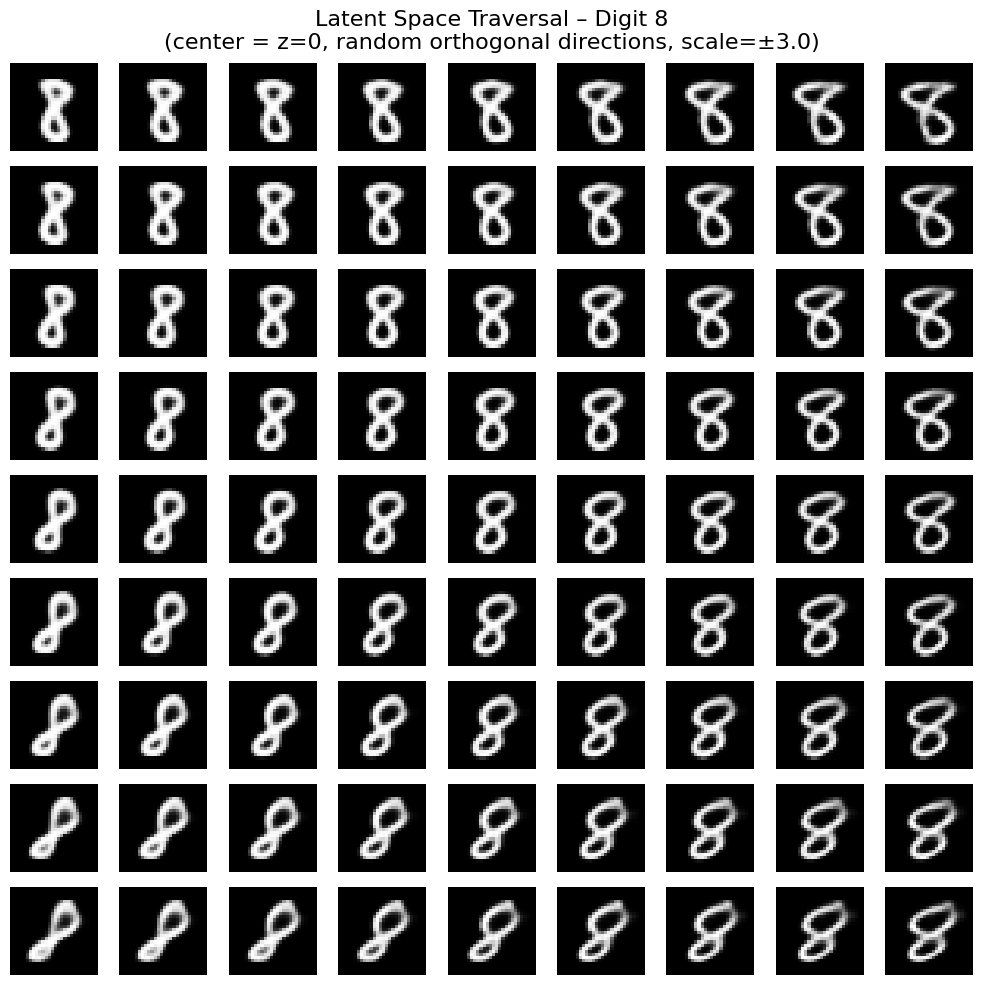

In [37]:
def visualize_latent_space(model, y_label=5, z_dim=16, grid_size=9, scale=3.0, device=None):
    """
    9×9 latent space traversal for a fixed digit.
    Works whether the model is on CPU or CUDA.
    """
    if device is None:
        device = next(model.parameters()).device          # auto-detect where model lives

    model.eval()

    # ------------------- 1. Fixed label (all 81 images have the same digit) -------------------
    n_samples = grid_size * grid_size
    y = torch.full((n_samples,), y_label, dtype=torch.long, device=device)
    y_onehot = F.one_hot(y, num_classes=10).float()       # (81, 10) already on correct device

    # ------------------- 2. Two random (roughly orthogonal) latent directions -------------------
    torch.manual_seed(42 + y_label)      # reproducible but different per digit
    dir1 = torch.randn(z_dim, device=device)
    dir2 = torch.randn(z_dim, device=device)

    # Simple Gram-Schmidt to make them more orthogonal
    dir2 = dir2 - (dir2 @ dir1) * dir1 / (dir1 @ dir1 + 1e-8)
    dir1 = dir1 / dir1.norm()
    dir2 = dir2 / (dir2.norm() + 1e-8)

    # ------------------- 3. Grid coordinates -------------------
    lin = torch.linspace(-scale, scale, grid_size, device=device)
    grid_x, grid_y = torch.meshgrid(lin, lin, indexing='ij')
    grid_x = grid_x.reshape(-1)   # (81,)
    grid_y = grid_y.reshape(-1)

    # ------------------- 4. Build latent vectors z -------------------
    z = grid_x[:, None] * dir1 + grid_y[:, None] * dir2      # (81, z_dim)

    # ------------------- 5. Decode -------------------
    with torch.no_grad():
        samples = model.decoder(z, y_onehot)   # already on correct device → (81, 1, 28, 28)
        samples = samples.cpu()                # bring back to CPU for plotting

    # ------------------- 6. Plot 9×9 grid -------------------
    fig, axes = plt.subplots(grid_size, grid_size, figsize=(10, 10))
    for i in range(grid_size):
        for j in range(grid_size):
            idx = i * grid_size + j
            axes[i, j].imshow(samples[idx].squeeze(0), cmap='gray')
            axes[i, j].axis('off')

    plt.suptitle(f'Latent Space Traversal – Digit {y_label}\n'
                 f'(center = z=0, random orthogonal directions, scale=±{scale})',
                 fontsize=16)
    plt.tight_layout()
    plt.show()

# observe how style changes smoothly!
for digit in [0, 1, 3, 5, 7, 8]:
    print(f"\n=== Latent traversal for digit {digit} ===")
    visualize_latent_space(model, y_label=digit, z_dim=16, grid_size=9, scale=3.0)

### **Style-Controlled Student ID Generation**
Extend your CVAE to allow **style control** along a latent dimension.
Write a function that takes your **9-digit student ID** as input and generates one digit per number, arranged in a single row.
Additionally, for each digit, gradually vary the “style” dimension from thin to thick (or light to bold) as you move across the row, so that the same digit shows different styles.
Include the resulting image in your report and briefly describe how the style changes are reflected in the generated digits.


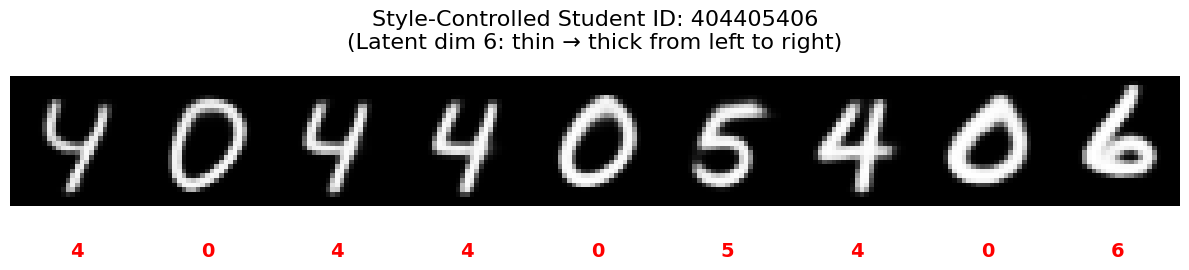

tensor([[8.4743e-06, 1.5064e-06, 1.6722e-06,  ..., 1.5677e-06, 2.3363e-06,
         5.5621e-06],
        [4.7424e-07, 7.0682e-08, 5.6095e-08,  ..., 2.0027e-06, 5.5440e-07,
         8.9223e-07],
        [4.2269e-07, 1.0324e-07, 1.1945e-07,  ..., 1.1215e-05, 6.7517e-06,
         8.9037e-07],
        ...,
        [1.2339e-05, 1.9948e-06, 7.6183e-07,  ..., 1.2844e-07, 2.0934e-07,
         7.1602e-07],
        [3.2363e-05, 1.2319e-06, 4.7401e-07,  ..., 5.3852e-08, 1.2282e-07,
         1.3978e-06],
        [1.2600e-04, 2.2088e-05, 1.6312e-06,  ..., 2.9713e-07, 1.7620e-06,
         4.1759e-05]])

In [49]:
def style_controlled_student_id(model, student_id, style_dim=0, scale=3.0, device='cpu'):
    """
    Generates student ID digits with progressive style variation along a chosen latent dimension.
    Assumes lower values → thin/light style, higher → thick/bold (tune style_dim based on prior exploration).
    
    Args:
        model: Trained CVAE
        student_id: int (9 digits, e.g., 404405406)
        style_dim: int, latent index for style control (0 to z_dim-1; pick from traversal viz)
        scale: float, range ±scale for interpolation
        device: 'cpu' or 'cuda'
    """
    model.eval()
    student_str = str(student_id)
    if len(student_str) != 9:
        raise ValueError("Student ID must be exactly 9 digits!")
    
    digits = [int(d) for d in student_str]
    n = 9
    
    # Latent values: linear from -scale to +scale
    style_values = torch.linspace(-scale, scale, n, device=device)  # (9,)
    
    with torch.no_grad():
        generated = []
        for i in range(n):
            # One-hot label
            y_label = torch.tensor([digits[i]], device=device)  # (1,)
            y = F.one_hot(y_label, num_classes=10).float()      # (1, 10)
            
            # Zero latent, vary only the style_dim
            z = torch.zeros(1, model.z_dim, device=device)      # (1, z_dim)
            z[0, style_dim] = style_values[i]
            
            # Generate single digit
            x_gen = model.decoder(z, y).cpu()                   # (1, 1, 28, 28)
            generated.append(x_gen)
        
        # Horizontal concat: (1, 1, 28, 252)
        strip = torch.cat(generated, dim=3).squeeze()           # squeeze all singletons → (28, 252)
        
        # Plot
        plt.figure(figsize=(12, 3))
        plt.imshow(strip, cmap='gray')
        plt.axis('off')
        plt.title(f"Style-Controlled Student ID: {student_id}\n"
                  f"(Latent dim {style_dim}: thin → thick from left to right)", 
                  fontsize=16, pad=20)
        
        # Add digit labels below each
        for i, d in enumerate(digits):
            plt.text(14 + 28*i, 35, str(d), fontsize=14, ha='center', va='top', 
                     color='red', weight='bold')
        
        plt.tight_layout()
        plt.show()
        
        return strip

# Example usage (choose style_dim from prior latent viz; e.g., one that controls thickness)
style_controlled_student_id(model, 404405406, style_dim=6, scale=3.0, device=device)  # Adjust style_dim as needed